# Cloud Cost EDA
Exploratory Data Analysis for the AI-Based Cloud Cost Root Cause Analyzer.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data
df = pd.read_csv('../data/processed/cloud_usage_processed.csv')
df.head()

,date,cpu_utilization,memory_utilization,storage_gb,network_transfer_gb,ec2_instances,rds_usage_hours,snapshot_count,autoscaling_events,lambda_invocations,daily_cost,root_cause,hour,day_of_week,is_weekend,cost_per_ec2
0,2025-10-06 18:36:31,28.881199,54.783533,1013.952065,601.051528,33,26,10,4,8838.243732,277.487182,Normal,18,0,0,8.408700
1,2025-10-06 19:36:31,42.419623,21.300796,913.754108,443.771247,37,83,19,2,10284.929205,421.140542,Normal,19,0,0,11.382174
2,2025-10-06 20:36:31,44.170111,62.486928,985.330043,497.016143,34,83,18,1,9719.563005,413.431924,Normal,20,0,0,12.159759
3,2025-10-06 21:36:31,47.791926,33.483534,1056.511410,537.311891,44,59,6,3,10417.727190,308.699371,Normal,21,0,0,7.015893
4,2025-10-06 22:36:31,89.191021,63.226416,949.545733,341.670579,49,76,12,14,10192.832958,393.880685,Auto Scaling,22,0,0,8.038380


In [2]:
# Dataset Statistics
df.describe()

,cpu_utilization,memory_utilization,storage_gb,network_transfer_gb,ec2_instances,rds_usage_hours,snapshot_count,autoscaling_events,lambda_invocations,daily_cost,hour,day_of_week,is_weekend,cost_per_ec2
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,43.666222,45.826780,1026.278902,651.862413,34.939900,74.329600,13.72360,2.925600,10011.522500,387.662227,11.498400,2.992000,0.283200,13.770334
std,22.140345,18.847569,155.777671,476.275808,16.620629,45.934893,9.02279,3.254985,1991.296676,87.431680,6.924767,1.995879,0.450575,7.592881
min,0.000000,0.000000,0.000000,129.120339,10.000000,24.000000,5.00000,0.000000,2445.520473,165.307409,0.000000,0.000000,0.000000,4.368665
25%,31.893375,35.154532,969.180978,441.217339,22.000000,45.000000,8.00000,1.000000,8685.592876,327.830436,5.000000,1.000000,0.000000,8.633031
50%,41.640160,47.868295,1005.807898,512.337410,34.000000,65.000000,12.00000,2.000000,10017.105565,374.046982,11.000000,3.000000,0.000000,11.374108
75%,53.753049,58.886012,1047.020555,596.472821,45.000000,87.000000,16.00000,4.000000,11331.237720,429.815358,18.000000,5.000000,1.000000,16.587471
max,100.000000,100.000000,1776.155623,3029.524878,97.000000,293.000000,68.00000,18.000000,17805.597435,759.599430,23.000000,6.000000,1.000000,65.736929


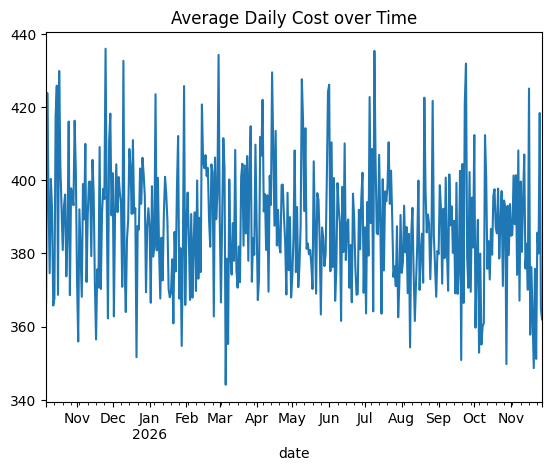

In [3]:
# Cost Trends
df['date'] = pd.to_datetime(df['date'])
df.set_index('date')['daily_cost'].resample('D').mean().plot(title='Average Daily Cost over Time')
plt.show()

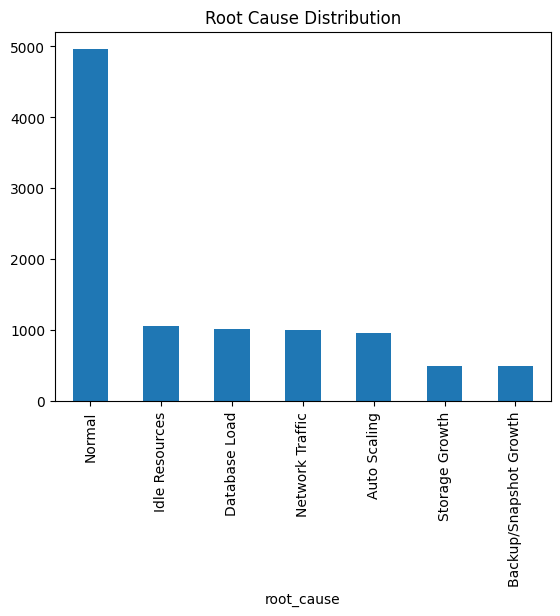

In [4]:
# Root-cause distribution
df['root_cause'].value_counts().plot(kind='bar', title='Root Cause Distribution')
plt.show()

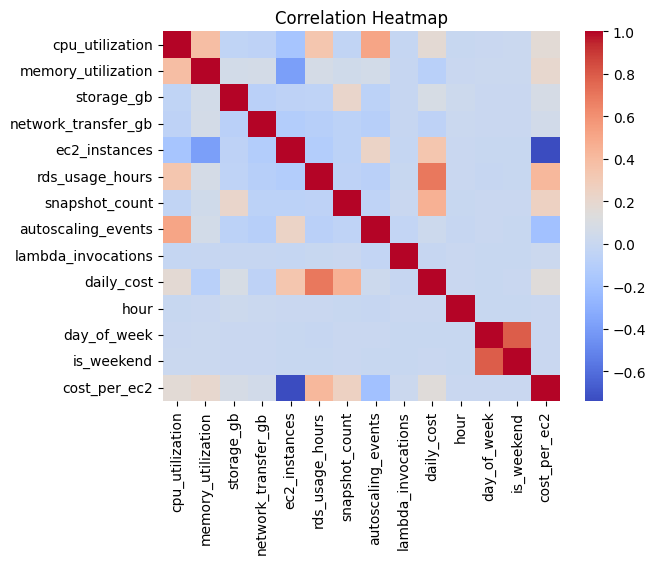

In [5]:
# Correlations
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()